# fasttext
https://github.com/facebookresearch/fastText

fasttextを用いて文書分類を行います。<BR>
なお、分類する文書は、ライブドアニュースとします。<BR>
対象のニュースは下記の５つとします。(5クラス分類)<BR>
<BR>
0=政治<BR>
1=海外<BR>
2=映画<BR>
3=スポーツ<BR>
4=宇宙<BR>
<BR>
ニュースは、スクレイピングにより訓練データを各100件、<BR>
検証データを各20件の合計500件をダウンロードします。<BR>

## 環境構築

In [19]:
#mecabライブラリの作成
!apt install -y libmecab-dev make mecab mecab-ipadic-utf8 
#Pythonバインディングの導入
!pip install mecab-python3
#追加辞書IPADIC-NEologdの導入資源を取得
!git clone --depth 1 https://github.com/neologd/mecab-ipadic-neologd.git
#fileコマンドが無いため導入しておく
!sudo apt install file
#IPADIC-NEologd辞書の導入
!echo yes | mecab-ipadic-neologd/bin/install-mecab-ipadic-neologd -n -a
#runtimeエラーが起きるので、それに対する対処
# https://github.com/SamuraiT/mecab-python3#common-issues
!pip install unidic-lite
#fasttextの導入
!pip install fasttext
#表データ処理のpandasを導入
!pip install pandas
#科学計算ライブラリを導入
!pip install scikit-learn
#描画ライブラリの導入
!pip install matplotlib
#描画ライブラリの導入（グラフ)
!pip install seaborn

E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
fatal: destination path 'mecab-ipadic-neologd' already exists and is not an empty directory.
/usr/bin/sh: 1: sudo: not found
[install-mecab-ipadic-NEologd] : Start..
[install-mecab-ipadic-NEologd] : Check the existance of libraries
[install-mecab-ipadic-NEologd] :     find => ok
[install-mecab-ipadic-NEologd] :     sort => ok
[install-mecab-ipadic-NEologd] :     head => ok
[install-mecab-ipadic-NEologd] :     cut => ok
[install-mecab-ipadic-NEologd] :     egrep => ok
[install-mecab-ipadic-NEologd] :     mecab is not found.


## 分類器の開発

In [20]:
import pandas as pd
import time
from datetime import datetime
import urllib.request
from bs4 import BeautifulSoup
from time import sleep
import fasttext as ft
import MeCab
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# Gドライブへの保管先パスを定義
nlpDataPath = './nlpData/'
os.makedirs(nlpDataPath, exist_ok=True)

### スクレイピング

In [21]:
# [関数] 指定されたカテゴリのニュース一覧を取得し、タイトルをtitles設定する
def getNewsTitle(url, titles):
  # ニュース一覧のhtmlを取得
  html = urllib.request.urlopen(url)
  # htmlを分析しsoupオブジェクトを得る
  soup = BeautifulSoup(html, "html.parser")

  #<li>タグを探す、ニュースはこの中にある
  contents = soup.find_all("li")
  
  # 得られたliタグのコンテンツリストを順に処理
  for content in contents:
    #<h3>タグを探す、ニュースタイトルはこの中にある
    topic = content.find('h3')
    if (topic != None):
      #aタグを探す
      link = content.find('a')
      #リンクを取得（今回未使用となりますが）
      detailLink = link.get('href')
      #ニュースタイトルを取得し、 titlesに設定
      ##print('debug1 ', topic)
      ##print('debug2 ', topic.text)
      ##print('debug3 ', type(topic.text))

      #titles.append(str(topic.text) )
      titles.append(topic.text)

In [22]:
# ニュースを取り出すルートURL
# 最後のp=にページ番号を与えることで複数のページに切り替えてアクセスする。
# リストは順に、ラベル、ラベル名称（日本語）、ニュースカテゴリへのURL
urllist = [
    ['__label__0', '政治', 'https://news.livedoor.com/article/category/1/?p='],
    ['__label__1', '海外',  'https://news.livedoor.com/topics/category/world/?p='],
    ['__label__2', '映画', 'https://news.livedoor.com/article/category/52/?p='],
    ['__label__3',  'スポーツ', 'https://news.livedoor.com/topics/category/sports/?p=1'],
    ['__label__4',  '宇宙', 'https://news.livedoor.com/topics/keyword/32398/?p='],
]

In [23]:
# 訓練データを格納するtrainData
trainData = []
# 検証データを格納するvalidationData
validationData=[]

# 分かち書きを行うため形態素解析器を準備
mc = MeCab.Tagger('-Owakati')

# 訓練データの作成
print('--- 訓練データの収集')
#ニュースカテゴリ数分実行
for u in urllist:
  titles = []
  # １ページから順に５ページまでアクセス
  for i in range(5):
    # urlを組み立て、u[2]はullistの２番目の要素（ニュースサイトへのURL)
    # iをページ番号として利用するため、u[2]と結合する
    url = u[2]+str(i+1)
    # アクセスするURLを表示(進行条項確認のため)
    print(u[0], u[1], url)
    # ニュース取得関数を実行
    getNewsTitle(url, titles)
    # ニュースサイトに負荷をかけないためにスリープ
    sleep(0.5) #0.5秒sleep
  
  # １ページにつき20件のニュースを取得。
  # ラベル(u[0])と取得したニュースタイトルを分かち書きして、trainDataに追加
  for t in titles:
    trainData.append('{}, {}'.format(u[0], mc.parse(t)))

#検証データの作成
print('--- 検証データの収集')
#ニュースカテゴリ数分実行
for u in urllist:
  titles = []
  url = u[2]+str(i+2)
  print(u[0], u[1], url)
  getNewsTitle(url, titles)
  sleep(0.5) #0.5秒sleep
  
  for t in titles:
    validationData.append('{}, {}'.format(u[0], re.sub('\n', '', mc.parse(t))))

--- 訓練データの収集
__label__0 政治 https://news.livedoor.com/article/category/1/?p=1
__label__0 政治 https://news.livedoor.com/article/category/1/?p=2
__label__0 政治 https://news.livedoor.com/article/category/1/?p=3
__label__0 政治 https://news.livedoor.com/article/category/1/?p=4
__label__0 政治 https://news.livedoor.com/article/category/1/?p=5
__label__1 海外 https://news.livedoor.com/topics/category/world/?p=1
__label__1 海外 https://news.livedoor.com/topics/category/world/?p=2
__label__1 海外 https://news.livedoor.com/topics/category/world/?p=3
__label__1 海外 https://news.livedoor.com/topics/category/world/?p=4
__label__1 海外 https://news.livedoor.com/topics/category/world/?p=5
__label__2 映画 https://news.livedoor.com/article/category/52/?p=1
__label__2 映画 https://news.livedoor.com/article/category/52/?p=2
__label__2 映画 https://news.livedoor.com/article/category/52/?p=3
__label__2 映画 https://news.livedoor.com/article/category/52/?p=4
__label__2 映画 https://news.livedoor.com/article/category/52/?p=5
__label

In [24]:
#ダウンロードしたデータはファイルに保存しておく
#訓練データの保存
with open(nlpDataPath+'ftTrainData.txt', 'w') as f:
  for td in trainData:
    f.write(td+'\n')

#検証データの保存
with open(nlpDataPath+'ftValidationData.txt', 'w') as f:
  for td in validationData:
    f.write(td)

### 学習

In [27]:
# fasttextの学習
model = ft.train_supervised(input=nlpDataPath+'ftTrainData.txt', epoch=1000, loss="hs")
model.save_model(nlpDataPath+'fasttext.model')

Read 0M words
Number of words:  3184
Number of labels: 5
Progress: 100.0% words/sec/thread: 1781015 lr:  0.000000 avg.loss:  0.022164 ETA:   0h 0m 0s


In [28]:
# ラベル名を数値１桁に変換する関数
# 文字列ラベル名は扱いにくいため
# __label__0 〜 __label3__を順に1,2,3,4に変換
def mklabel(label):
    resp = 0

    if label == '__label__0':
        resp = 0
    elif label == '__label__1':
        resp = 1
    elif label == '__label__2':
        resp = 2
    elif label == '__label__3':
        resp = 3
    else:
        resp = 4
    
    return resp

### 分類

In [29]:
# 正解のラベルを格納（数値）
y_true=[]
# 予測されたラベルを格納(数値)
y_pred=[]

# 検証データをtに取得し分類を行う。・
# 検証データがなくなるまで繰り返し
for t in validationData:
  # textに予測させるニュースタイトルを格納する
  # "__label__0, イチロー 氏 が" となっているため正規表現を使い
  # ニュースタイトル(text)と正解ラベル(corr)に分割する。
  text = re.sub('^.*, ', '', t)
  corr = re.sub(',.*$', '', t)
  # 予測させる
  label, prob = model.predict(text, k=1)
  # 正解ラベルを数値に変換してy_trueへ格納
  # のちの精度評価のため、ここで正解ラベルを数値にしておく
  y_true.append(mklabel(corr))
  # 予測された分類カテゴリのラベルに含まれる不要文字を正規表現で削除
  labelP = re.sub(',', '', label[0])
  # 予測された分類カテゴリを数値に変換
  # のちの精度評価のため、ここで予測された分類ラベルを数値にしておく
  y_pred.append(mklabel(labelP))
  # 正解と予測、予測の確信度、ニュースタイトルを表示する
  #print('正解={}, 予測={}, prob={}, text={}'.format(mklabel(corr), mklabel(labelP), prob, text))
  print('正解={}, 予測={}, prob={}'.format(mklabel(corr), mklabel(labelP), prob))
    

正解=0, 予測=0, prob=[0.99891835]
正解=0, 予測=0, prob=[0.99979949]
正解=0, 予測=0, prob=[0.99977708]
正解=0, 予測=0, prob=[0.99949718]
正解=0, 予測=0, prob=[0.85811949]
正解=0, 予測=0, prob=[0.99975032]
正解=0, 予測=0, prob=[0.99855858]
正解=0, 予測=0, prob=[0.99322355]
正解=0, 予測=0, prob=[0.99999142]
正解=0, 予測=0, prob=[0.98371536]
正解=0, 予測=0, prob=[1.00001907]
正解=0, 予測=0, prob=[0.99320143]
正解=0, 予測=0, prob=[1.00001085]
正解=0, 予測=3, prob=[0.99991745]
正解=0, 予測=0, prob=[0.64979291]
正解=0, 予測=0, prob=[0.99988842]
正解=0, 予測=3, prob=[0.50279129]
正解=0, 予測=3, prob=[0.78844774]
正解=0, 予測=0, prob=[0.95345294]
正解=0, 予測=3, prob=[0.90131593]
正解=1, 予測=3, prob=[0.93979377]
正解=1, 予測=1, prob=[0.6732204]
正解=1, 予測=1, prob=[0.85827035]
正解=1, 予測=1, prob=[0.99893415]
正解=1, 予測=1, prob=[0.54893082]
正解=1, 予測=3, prob=[0.5298754]
正解=1, 予測=4, prob=[0.78692842]
正解=1, 予測=1, prob=[0.77481693]
正解=1, 予測=1, prob=[0.99829865]
正解=1, 予測=1, prob=[0.97393519]
正解=1, 予測=1, prob=[0.99894071]
正解=1, 予測=1, prob=[0.77575541]
正解=1, 予測=1, prob=[0.96934819]
正解=1, 予測=3, 

### 評価

正解データ
0=政治
1=海外
2=映画
3=スポーツ
4=宇宙


<AxesSubplot: xlabel='class', ylabel='count'>

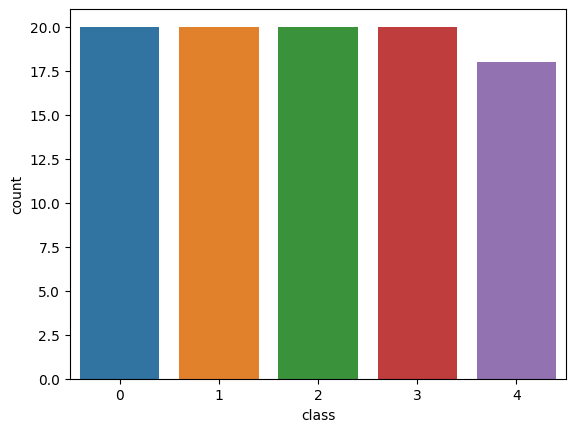

In [30]:
# ここで正解ラベルの分布を確認します。
# 各ラベル20件づつ取得していたので、
# グラフは同じになる事を確認します・
print('正解データ')
# 数値と分類クラスを表示
for u in urllist:
  print('{}={}'.format(mklabel(u[0]), u[1]))

# 描画ライブラリ(seaborn)を使ってグラフにプロットします
#sns.countplot(y_true)
pdy_true = pd.DataFrame(y_true, columns=["class"])
sns.countplot(data=pdy_true, x="class")

予測データ
0=政治
1=海外
2=映画
3=スポーツ
4=宇宙


<AxesSubplot: xlabel='class', ylabel='count'>

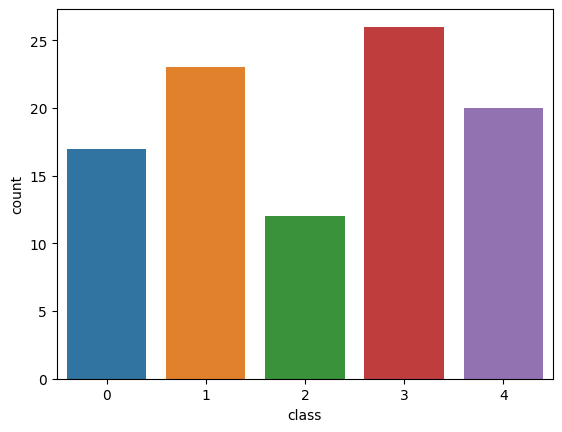

In [31]:
# 予測された分類結果をグラフ表示し、
# 結果を俯瞰します。
print('予測データ')
# 数値と分類クラスを表示
for u in urllist:
  print('{}={}'.format(mklabel(u[0]), u[1]))

# 描画ライブラリ(seaborn)を使ってグラフにプロットします
#sns.countplot(y_pred)
pdy_pred = pd.DataFrame(y_pred, columns=["class"])
sns.countplot(pdy_pred, x="class")

混同行列


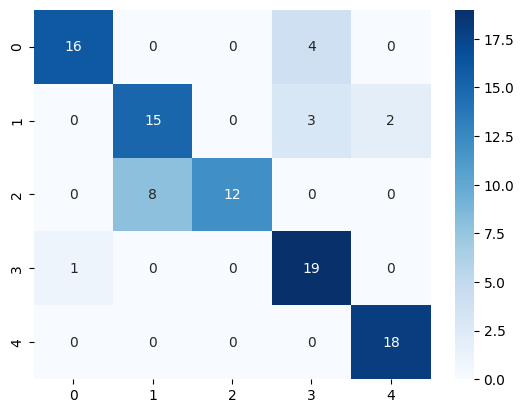

In [32]:
# 混同行列を表示し、分類精度を確認します
print('混同行列')
# 正解ラベルと予測した分類ラベルを指定して、混同行列を作成します。
cm = confusion_matrix(y_true, y_pred)
# 描画ライブラリ(seaborn)を使ってヒートマップをプロットします
sns.heatmap(cm, annot=True, cmap='Blues')
# プロットした混同行列を保存します
plt.savefig(nlpDataPath+'confusion_matrixsample.png')
